# Project Title: Tata Steel Machine Failure Prediction
# Project Type: Classification


In [136]:
# requred libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading tata_steel_failure data
df=pd.read_csv("Tata_Steel_Failure.csv")

In [3]:
#shape of the data
df.shape

(136429, 14)

In [4]:
#first 5 rows
df.head(5)

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [5]:
#last 5 rows
df.tail()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
136424,136424,M22284,M,300.1,311.4,1530,37.5,210,0,0,0,0,0,0
136425,136425,H38017,H,297.5,308.5,1447,49.1,2,0,0,0,0,0,0
136426,136426,L54690,L,300.5,311.8,1524,38.5,214,0,0,0,0,0,0
136427,136427,L53876,L,301.7,310.9,1447,46.3,42,0,0,0,0,0,0
136428,136428,L47937,L,296.9,308.1,1557,39.3,229,0,0,0,0,0,0


In [6]:
#name of the columns
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [7]:
# Want to replace the space by "_"  and suqre brackets([]) in column name
new_col=[]
for name in df.columns:
    new_name=name.replace(" ","_").replace("[","").replace("]","")
    new_col.append(new_name)

In [8]:
#renaming
df.rename(columns=dict(zip(df.columns,new_col)), inplace=True)

In [9]:
#info-regarding the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     136429 non-null  int64  
 1   Product_ID             136429 non-null  object 
 2   Type                   136429 non-null  object 
 3   Air_temperature_K      136429 non-null  float64
 4   Process_temperature_K  136429 non-null  float64
 5   Rotational_speed_rpm   136429 non-null  int64  
 6   Torque_Nm              136429 non-null  float64
 7   Tool_wear_min          136429 non-null  int64  
 8   Machine_failure        136429 non-null  int64  
 9   TWF                    136429 non-null  int64  
 10  HDF                    136429 non-null  int64  
 11  PWF                    136429 non-null  int64  
 12  OSF                    136429 non-null  int64  
 13  RNF                    136429 non-null  int64  
dtypes: float64(3), int64(9), object(2)
m

In [10]:
#categorical data
categorical=df.select_dtypes(include="object")

In [11]:
#numerical data
numerical=df.select_dtypes(include=["int64","float64"])

In [12]:
#describe the numerical data
numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
id,136429.0,68214.000000,39383.804275,0.0,34107.0,68214.0,102321.0,136428.0
Air_temperature_K,136429.0,299.862776,1.862247,295.3,298.3,300.0,301.2,304.4
Process_temperature_K,136429.0,309.941070,1.385173,305.8,308.7,310.0,310.9,313.8
Rotational_speed_rpm,136429.0,1520.331110,138.736632,1181.0,1432.0,1493.0,1580.0,2886.0
Torque_Nm,136429.0,40.348643,8.502229,3.8,34.6,40.4,46.1,76.6
Tool_wear_min,136429.0,104.408901,63.965040,0.0,48.0,106.0,159.0,253.0
Machine_failure,136429.0,0.015744,0.124486,0.0,0.0,0.0,0.0,1.0
TWF,136429.0,0.001554,0.039389,0.0,0.0,0.0,0.0,1.0
HDF,136429.0,0.005160,0.071649,0.0,0.0,0.0,0.0,1.0
PWF,136429.0,0.002397,0.048899,0.0,0.0,0.0,0.0,1.0


In [13]:
#describe the categorical data
categorical.describe()

,Product_ID,Type
count,136429,136429
unique,9976,3
top,L53257,L
freq,139,95354


In [14]:
#checking the missing or null values
df.isnull().sum().sum()

np.int64(0)

In [15]:
#Checking the duplicate values
df.duplicated().sum()

np.int64(0)

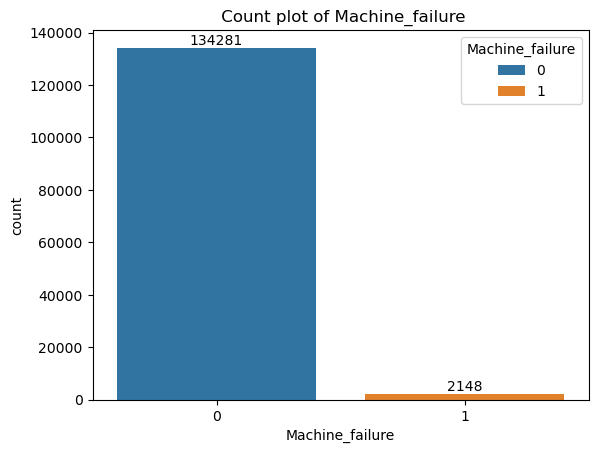

In [19]:
#countplot for machine failure

ax=sns.countplot(data=df,x="Machine_failure", hue="Machine_failure")

#ax.bar_label(ax.containers[0])
for container in ax.containers:
   
    ax.bar_label(container)
plt.title(" Count plot of Machine_failure")
plt.savefig("Count_plot_Machine_Failure.png")
plt.show()


In [20]:
df["Machine_failure"].value_counts()

Machine_failure
0    134281
1      2148
Name: count, dtype: int64

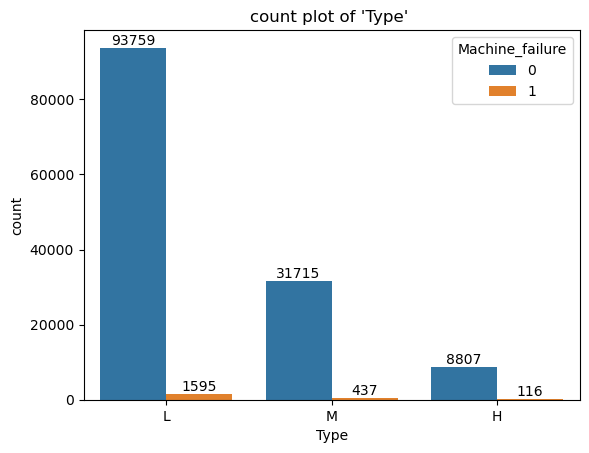

In [21]:
#count plot of "Type"
ax=sns.countplot(data=df,x="Type", hue="Machine_failure")
for container in ax.containers:


    ax.bar_label(container)
   # print([f'{r:.1%}' for r in ratios])
plt.title("count plot of 'Type' ")
plt.savefig("count_plot_of_'Type'.png")
plt.show()
    

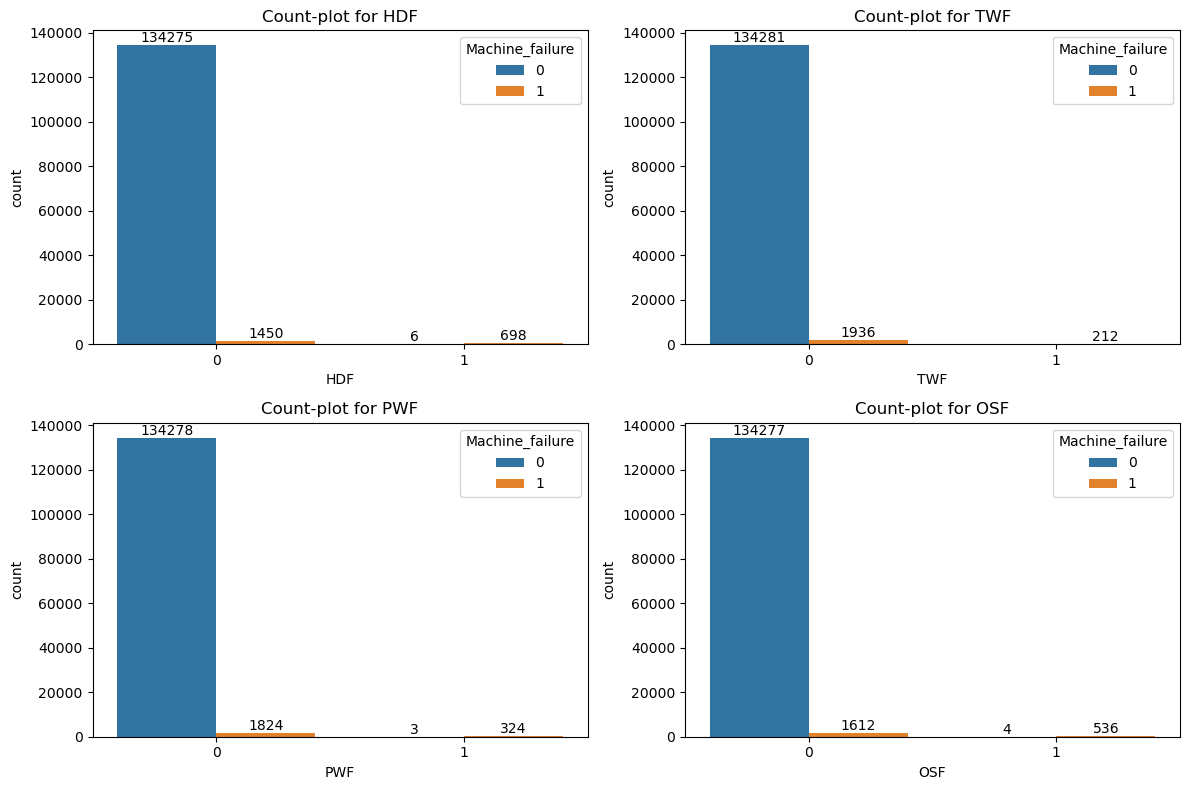

In [22]:
# count plot of HDF, TWF, PWF, OSF

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
ax1=sns.countplot(data=df,x="HDF",hue="Machine_failure")
for container in ax1.containers:
    ax1.bar_label(container)
plt.title("Count-plot for HDF")
plt.subplot(2,2,2)
ax2=sns.countplot(data=df,x="TWF",hue="Machine_failure")
for container in ax2.containers:
    ax2.bar_label(container)
plt.title("Count-plot for TWF")
plt.subplot(2,2,3)
ax3=sns.countplot(data=df,x="PWF",hue="Machine_failure")
for container in ax3.containers:
    ax3.bar_label(container)
plt.title("Count-plot for PWF")
plt.subplot(2,2,4)
ax4=sns.countplot(data=df,x="OSF",hue="Machine_failure")
for container in ax4.containers:
    ax4.bar_label(container)
plt.title("Count-plot for OSF")
plt.tight_layout()
plt.savefig("cnt_HDF_TWF_OSF.png")
plt.show()

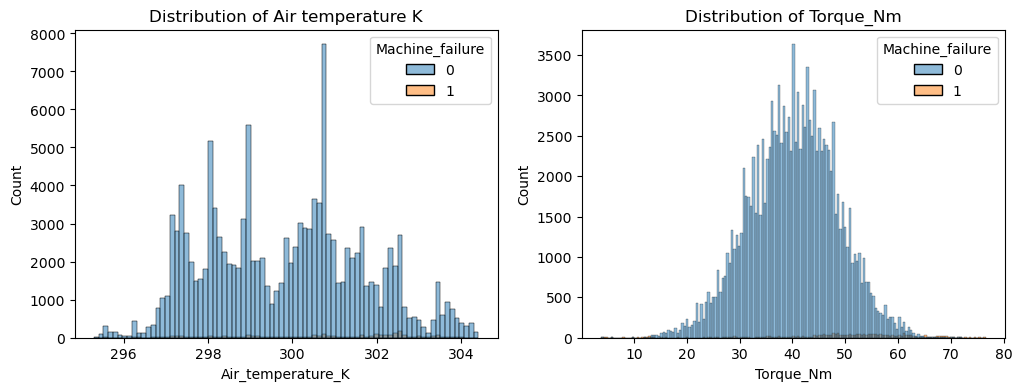

In [23]:
# Histogram plot of Air Temp and Torque 

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data=df,x="Air_temperature_K",hue="Machine_failure")
plt.title("Distribution of Air temperature K")
plt.subplot(1,2,2)
sns.histplot(data=df,x="Torque_Nm",hue="Machine_failure")
plt.title("Distribution of Torque_Nm")
plt.savefig("hist_plot.png")
plt.show()

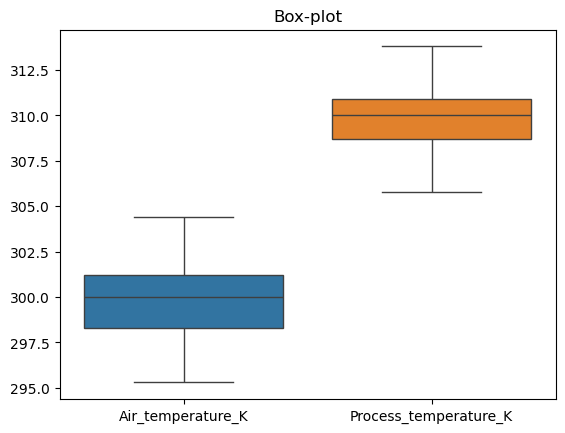

In [24]:
#Checking the outliers using box-plot
sns.boxplot(data=numerical[["Air_temperature_K","Process_temperature_K"]])
plt.title("Box-plot")
plt.savefig("boxplot.png")
plt.show()

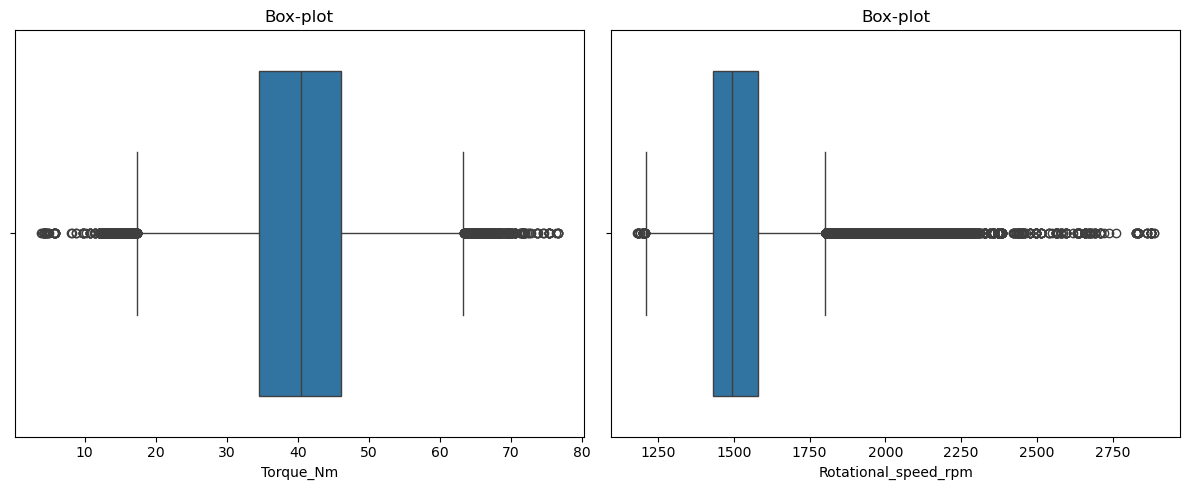

In [25]:
# Box plot of the individual col: "Rating", "Review","Size" and "Installs"

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=df,x="Torque_Nm")
plt.title("Box-plot")
plt.subplot(1,2,2)
sns.boxplot(data=df,x="Rotational_speed_rpm")
plt.tight_layout()
plt.title("Box-plot")
plt.savefig("boxplt2.png")
plt.show()

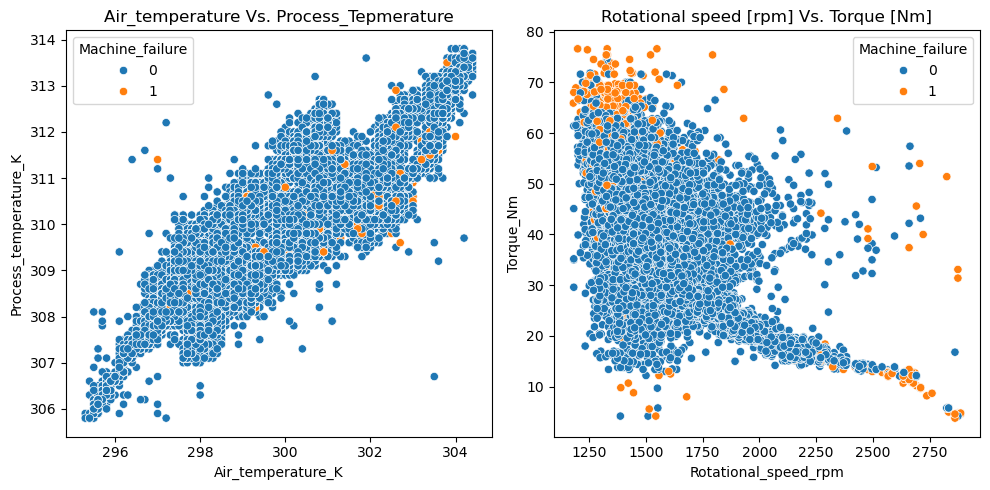

In [26]:
# Scatter plot between Air_temperature and Process_temperature & Rotational_speed and Torque
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.scatterplot(data=df,x="Air_temperature_K",y="Process_temperature_K",hue="Machine_failure")
plt.title("Air_temperature Vs. Process_Tepmerature")
plt.subplot(1,2,2)
sns.scatterplot(data=df,x="Rotational_speed_rpm",y="Torque_Nm", hue="Machine_failure")
plt.title("Rotational speed [rpm] Vs. Torque [Nm]")
plt.tight_layout()
plt.savefig("pairplot2.png")
plt.show()

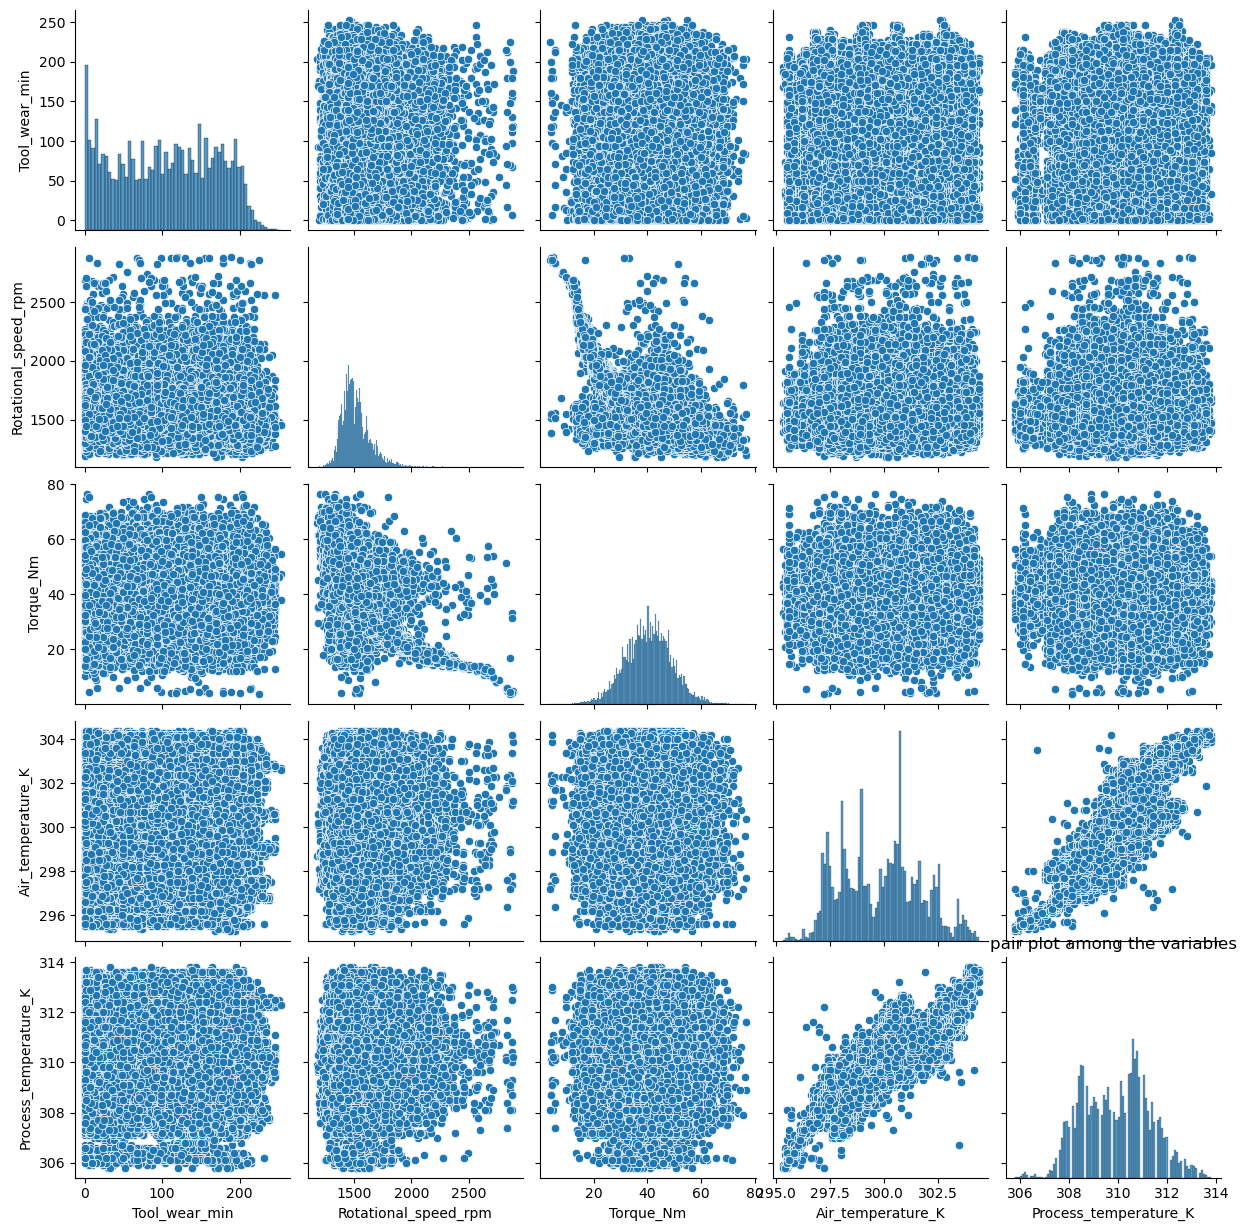

In [27]:
#pair plot among the "Tool wear [min]","Rotational speed [rpm]","Torque [Nm]","Air temperature [K]","Process temperature [K]"
sns.pairplot(data=df[["Tool_wear_min","Rotational_speed_rpm","Torque_Nm","Air_temperature_K","Process_temperature_K"]])
plt.title("pair plot among the variables")
plt.savefig("pairplot1.png")
plt.show()

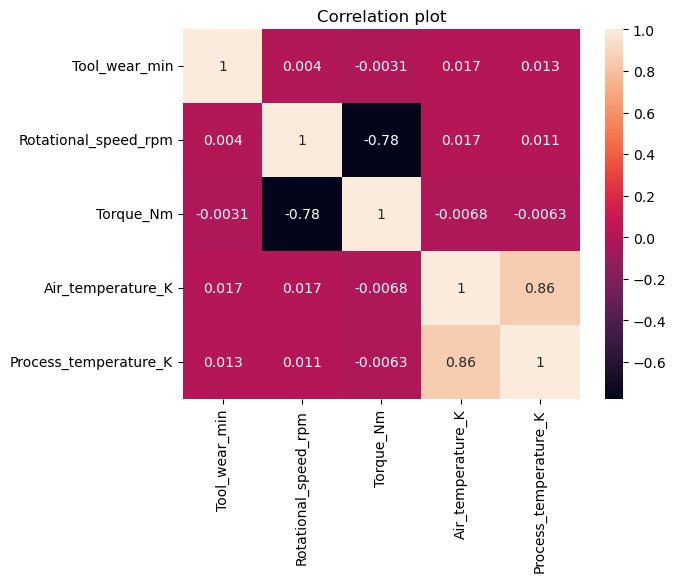

In [28]:
#correlation plot among the features
sns.heatmap(df[["Tool_wear_min","Rotational_speed_rpm","Torque_Nm","Air_temperature_K","Process_temperature_K"]].corr(),annot=True)
plt.title("Correlation plot")
plt.savefig("correlation1.png")
plt.show()

In [29]:
# Outlier handaling  of the features "Torque_[Nm]" and  "Rotational_speed_[rpm]"
# Number of outliers of  "Torque_[Nm]"

IQR_Torque=df["Torque_Nm"].quantile(0.75)-df["Torque_Nm"].quantile(0.25)
Outlier_Torque=df[(df["Torque_Nm"]>(df["Torque_Nm"].quantile(0.75)+1.5*IQR_Torque))|(df["Torque_Nm"]<(df["Torque_Nm"].quantile(0.25)-1.5*IQR_Torque))]
Outlier_Torque.shape

(1060, 14)

In [30]:
#checking how many postive and negative classes are present in outlier
Outlier_Torque["Machine_failure"].value_counts()

Machine_failure
0    718
1    342
Name: count, dtype: int64

In [31]:
#Recalling how many postive negative classes are present in the data set
df["Machine_failure"].value_counts()

Machine_failure
0    134281
1      2148
Name: count, dtype: int64

In [32]:
#log transformation
df["Torque2"]=df[["Torque_Nm"]].apply(lambda x: np.log(x))

In [33]:
# Outlier handaling  of the features "Torque_[Nm]" and  "Rotational_speed_[rpm]"
# Number of outliers of  "Torque_[Nm]" after log transformation

IQR_Torque2=df["Torque2"].quantile(0.75)-df["Torque2"].quantile(0.25)
Outlier_Torque2=df[(df["Torque2"]>(df["Torque2"].quantile(0.75)+1.5*IQR_Torque2))|(df["Torque2"]<(df["Torque2"].quantile(0.25)-1.5*IQR_Torque2))]
Outlier_Torque2.shape

(2594, 15)

In [34]:
from scipy.stats import boxcox

x_transformed, lambda_val = boxcox(df["Torque_Nm"])
df_box_cox=pd.DataFrame(x_transformed, columns=["box_cox"])
df_box_cox["Machine_failure"]=df["Machine_failure"]

In [35]:
IQR_Torque_box=df_box_cox["box_cox"].quantile(0.75)-df_box_cox["box_cox"].quantile(0.25)
Outlier_Torque_box=df_box_cox[(df_box_cox["box_cox"]>(df_box_cox["box_cox"].quantile(0.75)+1.5*IQR_Torque_box))|(df_box_cox["box_cox"]<(df_box_cox["box_cox"].quantile(0.25)-1.5*IQR_Torque_box))]
Outlier_Torque_box.shape

(1013, 2)

In [ ]:
# So far we have done  EDA.....

In [ ]:
# Now we will do Machine learning for machine failure

In [39]:
# We will drop the columns.. 'id', 'Product_ID', 'Type','Process_temperature_K','Machine_failure','Torque2']
# as it is obvious theat these features don't contribute in prediction of machine failure
X1=df.drop(columns=['id', 'Product_ID','Type','Process_temperature_K','Machine_failure','Torque2'])
Y=df[["Machine_failure"]]

In [40]:

import category_encoders as ce
# Apply one-hot encoding
one_hot_encoder = ce.OneHotEncoder()
df_one_hot = one_hot_encoder.fit_transform(df['Type'])
X=pd.concat([df_one_hot,X1],axis=1)

In [43]:
X

,Type_1,Type_2,Type_3,Air_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,TWF,HDF,PWF,OSF,RNF
0,1,0,0,300.6,1596,36.1,140,0,0,0,0,0
1,0,1,0,302.6,1759,29.1,200,0,0,0,0,0
2,1,0,0,299.3,1805,26.5,25,0,0,0,0,0
3,1,0,0,301.0,1524,44.3,197,0,0,0,0,0
4,0,1,0,298.0,1641,35.4,34,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
136424,0,1,0,300.1,1530,37.5,210,0,0,0,0,0
136425,0,0,1,297.5,1447,49.1,2,0,0,0,0,0
136426,1,0,0,300.5,1524,38.5,214,0,0,0,0,0
136427,1,0,0,301.7,1447,46.3,42,0,0,0,0,0


In [44]:
# Feature selection using Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# 1. Initialize the Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')

# 2. Wrap it in SelectFromModel
# 'threshold' can be a number or a string like "mean" or "median"
selector = SelectFromModel(estimator=rf, threshold=0.05) #Here we have use thresold value=0.05..it will be clear when we 
#look at the feature importance graph

# 3. Fit to data
selector.fit(X,np.reshape(Y,(len(Y))))

SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                 random_state=42),
                threshold=0.05)

In [45]:
importances = selector.estimator_.feature_importances_

# Map them to the original column names
feature_scoring = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Score': importances
})

# Sort by importance (highest to lowest)
feature_scoring = feature_scoring.sort_values(by='Importance_Score', ascending=False)

print(feature_scoring)

                 Feature  Importance_Score
4   Rotational_speed_rpm          0.230460
5              Torque_Nm          0.223914
6          Tool_wear_min          0.121075
8                    HDF          0.102759
3      Air_temperature_K          0.087717
10                   OSF          0.087266
7                    TWF          0.070083
9                    PWF          0.066646
0                 Type_1          0.003761
1                 Type_2          0.003254
2                 Type_3          0.002574
11                   RNF          0.000492


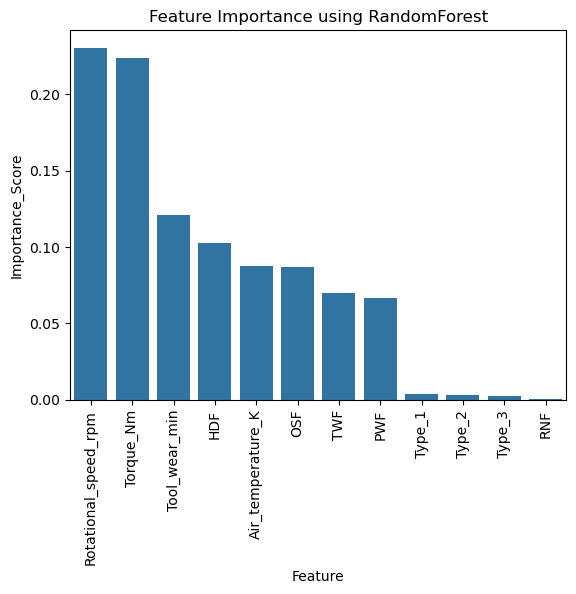

In [46]:
sns.barplot(data=feature_scoring,x="Feature",y="Importance_Score")
plt.title("Feature Importance using RandomForest")
plt.xticks(feature_scoring["Feature"], rotation=90)
plt.show()

In [47]:
# Get the names of the features that were kept
important_feature_names = selector.get_feature_names_out()

In [48]:

with open("best_featurs.txt","w") as f:
    for feature in important_feature_names:
          f.write(f"{feature}\n")

In [49]:
with open("best_featurs.txt","r") as f:
    x=f.read()
    print(x)

Air_temperature_K
Rotational_speed_rpm
Torque_Nm
Tool_wear_min
TWF
HDF
PWF
OSF



In [50]:
#Transform into selected features
X_transform=selector.transform(X)

In [51]:
# Train-test splitting with stratify as the dataset is imbalanced
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_transform,Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [52]:
from imblearn.over_sampling import RandomOverSampler

ROS=RandomOverSampler(random_state=42)
X_ros,y_ros=ROS.fit_resample(X_train,y_train)

In [53]:
# Model Training
#from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier






models = {

    "DecisionTree": {
            "model": DecisionTreeClassifier(
                criterion="gini",
                class_weight="balanced",
                random_state=42),
            "params": {
                "max_depth": [3,5],
                "min_samples_split": [3,5],
                "min_samples_leaf": [2,3]
               # "ccp_alpha": [0.0, 0.001, 0.01],
               # "max_features": ["sqrt", "log2", None]
            }
        },
        "RandomForest": {
            "model": RandomForestClassifier( max_samples=0.8, random_state=42, bootstrap=True),
            "params": {

                "n_estimators": [100, 200],
                "max_depth": [10, 20],
                'min_samples_split': [5,7],
                "min_samples_leaf": [ 3, 5]
               # "max_samples":[0.5,0.8] # it works only if bootstrap=True, by default it is True
               # "max_features": ["sqrt", "log2", 0.5]
                # There will be no learning rate ..

                
            }
        },

       "GradientBoostingClassifier": {
            "model": GradientBoostingClassifier(subsample=0.8, learning_rate=0.01, random_state=42), # eval_metric='logloss' is NOT used
            "params": {
                    "n_estimators": [200, 400],
                    #": [0.01, 0.05],
                    "max_depth": [2, 3, 4]
                    #"subsample": [0.7, 0.8, 0.9]
                
            }
        },
"XGBoost": {
            "model": XGBClassifier(learning_rate=0.01,subsample=0.8, random_state=42, eval_metric='auc'),
            "params": {
                'n_estimators': [100,200],
                'max_depth': [3, 5] # depth is important it controls overfitting
               # 'learning_rate=0.01': [0.01,0.05],
                #'subsample': [0.8]
            }
        },
    
 "LGBMClassifier": {
              "model": LGBMClassifier(learning_rate=0.01,subsample=0.8, force_row_wise=True,verbose =-1, random_state=42),
           
                "params": {
                'n_estimators': [100,200],
                'max_depth': [5,8],
                'num_leaves': [20, 40] # which is very important, controls overfitting: num_leaves ≤ 2^(max_depth)

                    
            }


           
    }

    
}

In [54]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)




In [55]:
import os



model_dir='/Users/gopal/Desktop/ML/Capstone_ Project_Machine_Learning/models_over_sampling'

os.makedirs(model_dir, exist_ok=True)

In [56]:
#

import pickle
import joblib

from sklearn.model_selection import GridSearchCV
for name, cfg in models.items():
        print(f"\n🔍 Training {name}...")
        grid = GridSearchCV(cfg["model"], cfg["params"], cv=cv, scoring='f1')
        grid.fit(X_ros,np.reshape(y_ros,(len(y_ros),)))
        best_model = grid.best_estimator_
        model_path = os.path.join(model_dir, f"{name}_model.pkl")
        with open(model_path, "wb") as f:
            pickle.dump(best_model, f)
        print(best_model)


🔍 Training DecisionTree...
DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       min_samples_split=3, random_state=42)

🔍 Training RandomForest...
RandomForestClassifier(max_depth=20, max_samples=0.8, min_samples_leaf=3,
                       min_samples_split=5, random_state=42)

🔍 Training GradientBoostingClassifier...
GradientBoostingClassifier(learning_rate=0.01, max_depth=4, n_estimators=400,
                           random_state=42, subsample=0.8)

🔍 Training XGBoost...
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_ca

/Users/gopal/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gopal/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gopal/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gopal/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gopal/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWa

LGBMClassifier(force_row_wise=True, learning_rate=0.01, max_depth=8,
               n_estimators=200, num_leaves=40, random_state=42, subsample=0.8,
               verbose=-1)


In [57]:
# import evaluation metric
##########################
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,roc_curve,auc

In [132]:
####Ploting confusion matrix ####
#################################

#model_path = '/Users/gopal/Desktop/ML/Capstone_ Project_Machine_Learning/models_over_sampling'
graph_dir="Model_graphs"
Model_graphs=os.path.join(model_dir,graph_dir)
os.makedirs(Model_graphs,exist_ok=True)

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True,xticklabels=[1, 0], 
            yticklabels=[1, 0])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    path = os.path.join(Model_graphs, f"{model_name}_confusion_matrix.png")
    plt.savefig(path)
    plt.close()
    return path

In [59]:
###Plotting ROC Curve ######
############################
def plot_roc_curve(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    path = os.path.join(Model_graphs, f"{model_name}_roc_curve.png")
    plt.savefig(path)
    plt.close()
    return path


In [133]:
# Function for Model Evaluation
################################




def evaluate_models(X_test, y_test, model_path=model_dir):
    model_files = [f for f in os.listdir(model_path) if f.endswith('_model.pkl')]
    results = {}
    models_dict = {}

    for model_file in model_files:
        model_name = model_file.replace('_model.pkl', '')
        print(f"\n📦 Loading {model_name}...")
        with open(os.path.join(model_path, model_file), 'rb') as f:
            model = pickle.load(f)
            models_dict[model_name] = model

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        acc = round(accuracy_score(y_test, y_pred),2)
        prec = round(precision_score(y_test, y_pred),2)
        rec = round(recall_score(y_test, y_pred),2)
        f1 = round(f1_score(y_test, y_pred),2)
        auc_score = round(roc_auc_score(y_test, y_prob),2)
        
        print(f"📊 Accuracy: {acc:.2f}, Precision: {prec:.2f}, Recall: {rec:.2f}, F1: {f1:.2f}, AUC: {auc_score:.2f}")
        #print("📋 Classification Report:")
        #print(classification_report(y_test, y_pred))

        plot_confusion_matrix(y_test, y_pred, model_name)
        plot_roc_curve(y_test, y_prob, model_name)

        results[model_name] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "roc_auc": auc_score
        }

    print("\n✅ All models evaluated!")

    # 🔍 Select Best Model Based on Accuracy (can change to 'roc_auc' or 'f1_score')
    best_model_name = max(results, key=lambda x: results[x]['f1_score'])
    best_model = models_dict[best_model_name]
    best_model_path = os.path.join(model_path, "best_model.pkl")
    joblib.dump(best_model, best_model_path)

    print(f"\n🏆 Best Model: {best_model_name}")
    print(f"✅ Saved best model to: {best_model_path}")

    
    return results



In [134]:
#Model evaluation
Model_Evaluation=evaluate_models(X_test, y_test, model_path=model_dir)


📦 Loading DecisionTree...
📊 Accuracy: 0.97, Precision: 0.35, Recall: 0.80, F1: 0.49, AUC: 0.92

📦 Loading GradientBoostingClassifier...
📊 Accuracy: 0.96, Precision: 0.25, Recall: 0.86, F1: 0.38, AUC: 0.95

📦 Loading RandomForest...
📊 Accuracy: 0.99, Precision: 0.86, Recall: 0.80, F1: 0.83, AUC: 0.94

📦 Loading LGBMClassifier...
📊 Accuracy: 0.97, Precision: 0.30, Recall: 0.85, F1: 0.44, AUC: 0.95


/Users/gopal/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gopal/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📦 Loading XGBoost...
📊 Accuracy: 0.96, Precision: 0.26, Recall: 0.86, F1: 0.40, AUC: 0.95

✅ All models evaluated!

🏆 Best Model: RandomForest
✅ Saved best model to: /Users/gopal/Desktop/ML/Capstone_ Project_Machine_Learning/models_over_sampling/best_model.pkl


In [135]:
joblib.load("/Users/gopal/Desktop/ML/Capstone_ Project_Machine_Learning/models_over_sampling/RandomForest_model.pkl")

RandomForestClassifier(max_depth=20, max_samples=0.8, min_samples_leaf=3,
                       min_samples_split=5, random_state=42)

# So, the Random Forest Classifier is the best model.